In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_auc_score,
                              accuracy_score)

print("✅ Saari libraries load ho gayi!")

✅ Saari libraries load ho gayi!


## data load ##

In [2]:
df = pd.read_csv('/kaggle/input/datasets/yashaskarsrivastava/credit-dataset/credit abhi.csv')

print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Shape: (1357, 10)

Missing Values:
 person_age               1357
person_income            1357
person_home_ownership    1357
person_emp_length        1357
loan_intent              1357
loan_grade               1357
loan_amnt                1357
loan_int_rate            1357
loan_status              1357
loan_percent_income      1357
dtype: int64


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
import os

# Dekho kaggle ne kya files di hain
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/laotse/credit-risk-dataset/credit_risk_dataset.csv
/kaggle/input/datasets/yashaskarsrivastava/credit-dataset/credit abhi.csv


In [4]:
df = pd.read_csv('/kaggle/input/datasets/yashaskarsrivastava/credit-dataset/credit abhi.csv')

print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Shape: (1357, 10)

Missing Values:
 person_age               1357
person_income            1357
person_home_ownership    1357
person_emp_length        1357
loan_intent              1357
loan_grade               1357
loan_amnt                1357
loan_int_rate            1357
loan_status              1357
loan_percent_income      1357
dtype: int64


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# File ke andar kya hai dekho
with open('/kaggle/input/datasets/yashaskarsrivastava/credit-dataset/credit abhi.csv', 'r') as f:
    # Pehli 5 lines print karo
    for i in range(5):
        print(f.readline())

person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income

,,,,,,,,,

,,,,,,,,,

,,,,,,,,,

,,,,,,,,,



In [6]:
import kagglehub

# Original dataset download karo
path = kagglehub.dataset_download("laotse/credit-risk-dataset")
print("Path:", path)

Path: /kaggle/input/datasets/laotse/credit-risk-dataset


In [7]:
df = pd.read_csv('/kaggle/input/datasets/laotse/credit-risk-dataset/credit_risk_dataset.csv')

print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Shape: (32581, 12)

Missing Values:
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## Data Cleaning ##

In [8]:
# Missing values fill karo (new way)
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# Categorical columns ko numbers mein badlo
df['person_home_ownership'] = df['person_home_ownership'].map(
    {'RENT': 0, 'OWN': 1, 'MORTGAGE': 2, 'OTHER': 3})

df['loan_intent'] = df['loan_intent'].map(
    {'PERSONAL': 0, 'EDUCATION': 1, 'MEDICAL': 2,
     'VENTURE': 3, 'HOMEIMPROVEMENT': 4, 'DEBTCONSOLIDATION': 5})

df['loan_grade'] = df['loan_grade'].map(
    {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6})

df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map(
    {'N': 0, 'Y': 1})

print("✅ Cleaning Done!")
print("\nMissing Values Ab:\n", df.isnull().sum())
df.head()

✅ Cleaning Done!

Missing Values Ab:
 person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,0,123.0,0,3,35000,16.02,1,0.59,1,3
1,21,9600,1,5.0,1,1,1000,11.14,0,0.10,0,2
2,25,9600,2,1.0,2,2,5500,12.87,1,0.57,0,3
3,23,65500,0,4.0,2,2,35000,15.23,1,0.53,0,2
4,24,54400,0,8.0,2,2,35000,14.27,1,0.55,1,4


## Feature Engineering + Split + Scale ##

In [9]:
# Naya feature banao
df['debt_to_income'] = df['loan_amnt'] / df['person_income']

# X = Input, y = Target
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale karo
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("✅ Feature Engineering Done!")
print(f"Training size : {X_train.shape}")
print(f"Testing size  : {X_test.shape}")

✅ Feature Engineering Done!
Training size : (26064, 12)
Testing size  : (6517, 12)


In [10]:
# Check karo koi NaN bacha hai kya
print("NaN values:\n", X.isnull().sum())

NaN values:
 person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
debt_to_income                0
dtype: int64


In [11]:
# Saare remaining NaN hatao
X = X.fillna(X.median(numeric_only=True))

# Ab split aur scale karo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("✅ Done! Koi NaN nahi bacha!")
print(f"Training size : {X_train.shape}")
print(f"Testing size  : {X_test.shape}")

✅ Done! Koi NaN nahi bacha!
Training size : (26064, 12)
Testing size  : (6517, 12)


In [12]:
import warnings
warnings.filterwarnings('ignore')

# Ab saare NaN hatao
X = X.fillna(X.median(numeric_only=True))

# Split aur scale karo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("✅ Done! Koi Warning Nahi!")
print(f"Training size : {X_train.shape}")
print(f"Testing size  : {X_test.shape}")

✅ Done! Koi Warning Nahi!
Training size : (26064, 12)
Testing size  : (6517, 12)


  ## Models Train ##

In [13]:
import warnings
warnings.filterwarnings('ignore')

# Dataset dobara load karo fresh
df = pd.read_csv('/kaggle/input/datasets/laotse/credit-risk-dataset/credit_risk_dataset.csv')

# Missing values fill karo
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# Categorical columns numbers mein badlo
df['person_home_ownership'] = df['person_home_ownership'].map(
    {'RENT': 0, 'OWN': 1, 'MORTGAGE': 2, 'OTHER': 3})
df['loan_intent'] = df['loan_intent'].map(
    {'PERSONAL': 0, 'EDUCATION': 1, 'MEDICAL': 2,
     'VENTURE': 3, 'HOMEIMPROVEMENT': 4, 'DEBTCONSOLIDATION': 5})
df['loan_grade'] = df['loan_grade'].map(
    {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6})
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map(
    {'N': 0, 'Y': 1})

# Naya feature
df['debt_to_income'] = df['loan_amnt'] / df['person_income']

# X aur y banao
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# Saare NaN ek baar mein hatao
X = X.fillna(X.median(numeric_only=True))

# Verify karo
print("NaN check:", X.isnull().sum().sum(), "← Ye 0 hona chahiye!")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"✅ Training size : {X_train.shape}")
print(f"✅ Testing size  : {X_test.shape}")
print("\n🎉 Ab Models Train Kar Sakte Hain!")

NaN check: 0 ← Ye 0 hona chahiye!
✅ Training size : (26064, 12)
✅ Testing size  : (6517, 12)

🎉 Ab Models Train Kar Sakte Hain!


In [14]:
# Model 1: Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
print("✅ Logistic Regression Done!")

# Model 2: Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
print("✅ Decision Tree Done!")

# Model 3: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("✅ Random Forest Done!")

print("\n🎉 Teeno Models Train Ho Gaye!")

✅ Logistic Regression Done!
✅ Decision Tree Done!
✅ Random Forest Done!

🎉 Teeno Models Train Ho Gaye!


 ## Model Evaluate ##

In [15]:
models = {
    'Logistic Regression': lr,
    'Decision Tree'      : dt,
    'Random Forest'      : rf
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{'='*45}")
    print(f"  📌 {name}")
    print(f"{'='*45}")
    print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
    print(classification_report(y_test, y_pred))


  📌 Logistic Regression
  Accuracy : 0.8459
  ROC-AUC  : 0.8530
              precision    recall  f1-score   support

           0       0.86      0.95      0.91      5072
           1       0.74      0.48      0.58      1445

    accuracy                           0.85      6517
   macro avg       0.80      0.71      0.74      6517
weighted avg       0.84      0.85      0.83      6517


  📌 Decision Tree
  Accuracy : 0.8938
  ROC-AUC  : 0.8474
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      5072
           1       0.76      0.76      0.76      1445

    accuracy                           0.89      6517
   macro avg       0.85      0.85      0.85      6517
weighted avg       0.89      0.89      0.89      6517


  📌 Random Forest
  Accuracy : 0.9280
  ROC-AUC  : 0.9354
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      5072
           1       0.96      0.71      0.81      1445


 ## Graphs ##

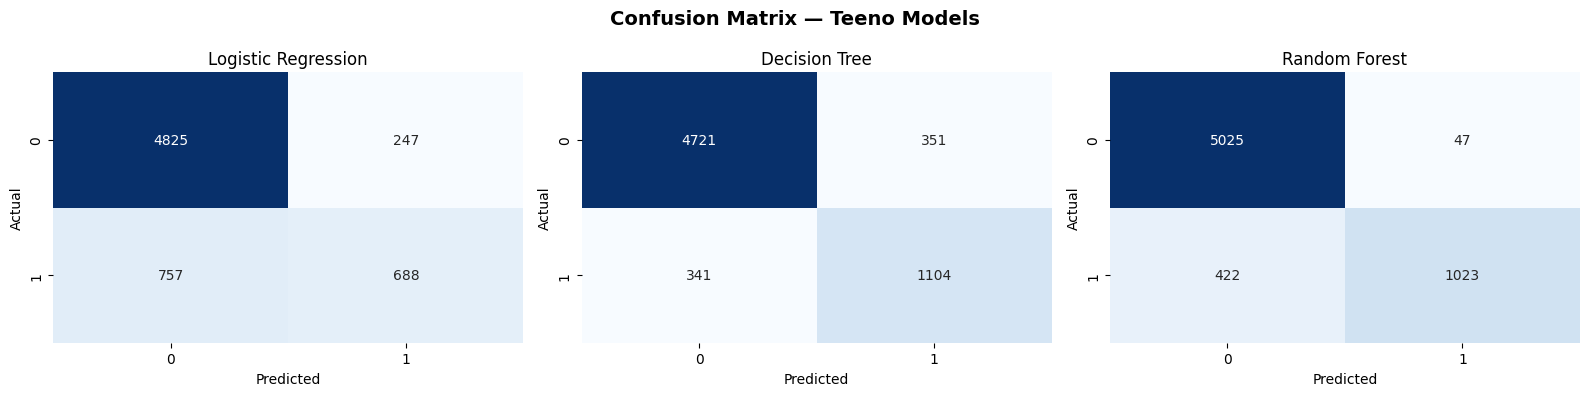

✅ Confusion Matrix Done!


In [16]:
# --- Graph 1: Confusion Matrix ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx],
                cmap='Blues', cbar=False)
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle('Confusion Matrix — Teeno Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Confusion Matrix Done!")

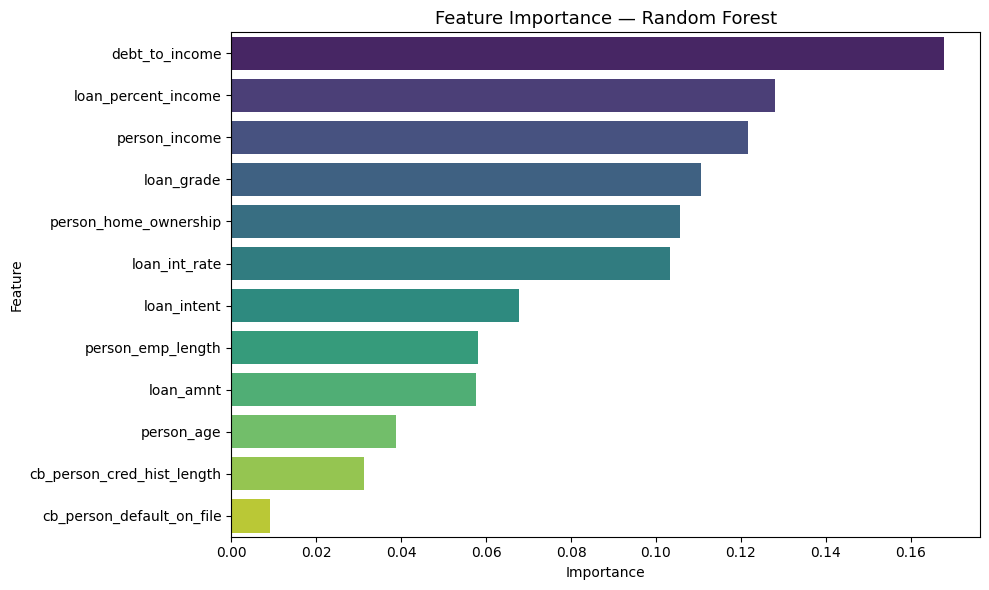

✅ Feature Importance Graph Done!


In [17]:
# --- Graph 2: Feature Importance ---
feat_names = df.drop('loan_status', axis=1).columns
feat_imp = pd.DataFrame({
    'Feature'   : feat_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
plt.title('Feature Importance — Random Forest', fontsize=13)
plt.tight_layout()
plt.show()
print("✅ Feature Importance Graph Done!")

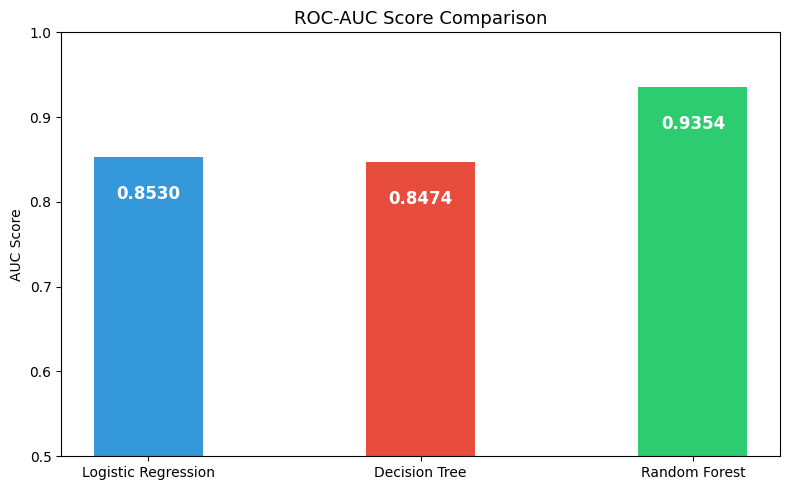

✅ ROC-AUC Graph Done!


In [18]:
# --- Graph 3: ROC-AUC Bar Chart ---
auc_scores = {}
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    auc_scores[name] = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 5))
bars = plt.bar(auc_scores.keys(), auc_scores.values(), 
               color=['#3498db','#e74c3c','#2ecc71'], width=0.4)

# Har bar pe value dikhao
for bar, val in zip(bars, auc_scores.values()):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() - 0.05,
             f'{val:.4f}', ha='center', 
             color='white', fontweight='bold', fontsize=12)

plt.ylim(0.5, 1.0)
plt.title('ROC-AUC Score Comparison', fontsize=13)
plt.ylabel('AUC Score')
plt.tight_layout()
plt.show()
print("✅ ROC-AUC Graph Done!")

## save ##

In [19]:
# Final Summary print karo
print("="*50)
print("   🏆 FINAL MODEL COMPARISON SUMMARY")
print("="*50)

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    print(f"\n  📌 {name}")
    print(f"     Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"     ROC-AUC  : {auc:.4f}")

print("\n" + "="*50)
print("  ✅ Task 1 Complete — Credit Scoring Model!")
print("  👨‍💻 CodeAlpha ML Internship")
print("="*50)

   🏆 FINAL MODEL COMPARISON SUMMARY

  📌 Logistic Regression
     Accuracy : 0.8459 (84.59%)
     ROC-AUC  : 0.8530

  📌 Decision Tree
     Accuracy : 0.8938 (89.38%)
     ROC-AUC  : 0.8474

  📌 Random Forest
     Accuracy : 0.9280 (92.80%)
     ROC-AUC  : 0.9354

  ✅ Task 1 Complete — Credit Scoring Model!
  👨‍💻 CodeAlpha ML Internship
